In [1]:
!pip install scikit-learn pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
df = pd.read_csv("academIQ_clean_dataset_v4.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())


Shape: (17543, 14)
   student_id  all_clicks  active_days  access_frequency  material_clicks  \
0        6516        2791          159         17.553459            174.0   
1        8462         646           56         11.535714             93.0   
2        8462         646           56         11.535714             93.0   
3       11391         934           40         23.350000             18.0   
4       23629         161           16         10.062500              2.0   

   avg_quiz_score  quiz_attempts  avg_assignment_score  \
0             0.0            0.0                  61.8   
1             0.0            0.0                  87.0   
2             0.0            0.0                  87.0   
3             0.0            0.0                  82.0   
4           100.0            2.0                  65.0   

   assignment_submissions  final_grade  risk_cluster  total_time_spent  \
0                     5.0           65             0              5582   
1                    

In [3]:
behavior_features = [
    "all_clicks",
    "active_days",
    "access_frequency",
    "material_clicks",
    "quiz_attempts",
    "assignment_submissions",
    "total_time_spent",
    "procrastination_index",
    "late_submission_count"
]

X = df[behavior_features]


In [4]:
df["high_performer"] = (df["final_grade"] >= 75).astype(int)
y = df["high_performer"]


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))

Accuracy: 0.8999715018523796
ROC-AUC: 0.8156132042855954


In [6]:
import pandas as pd

importances = pd.Series(
    model.feature_importances_,
    index=behavior_features
).sort_values(ascending=False)

print(importances)


all_clicks                0.145526
total_time_spent          0.141111
active_days               0.136237
procrastination_index     0.120430
access_frequency          0.104578
material_clicks           0.102223
quiz_attempts             0.098359
late_submission_count     0.088271
assignment_submissions    0.063265
dtype: float64


In [7]:
percentiles = X.rank(pct=True)


In [8]:
def generate_recommendations(student_index):
    student = X.iloc[student_index]
    student_percentile = percentiles.iloc[student_index]
    probability = model.predict_proba([student])[0][1]

    recs = []

    # Performance classification
    if probability < 0.4:
        recs.append("High risk of weak academic performance.")
    elif probability < 0.7:
        recs.append("Moderate performance level. Improvement possible.")
    else:
        recs.append("Strong behavioral performance pattern.")

    # Personalized weaknesses
    if student_percentile["procrastination_index"] > 0.7:
        recs.append("High procrastination detected. Start assignments earlier.")

    if student_percentile["late_submission_count"] > 0.7:
        recs.append("Frequent late submissions. Improve deadline management.")

    if student_percentile["access_frequency"] < 0.3:
        recs.append("Low platform access frequency. Engage more regularly.")

    if student_percentile["total_time_spent"] < 0.3:
        recs.append("Low study time compared to peers. Increase weekly study hours.")

    if student_percentile["quiz_attempts"] < 0.3:
        recs.append("Low quiz practice. Increase self-testing for better retention.")

    return {
        "Probability_of_High_Performance": probability,
        "Classification": "High Performer" if probability >= 0.5 else "Not High Performer",
        "Recommendations": recs
    }


In [9]:
df["short_term_risk"] = (
    (df["procrastination_index"] > df["procrastination_index"].median()) &
    (df["late_submission_count"] > df["late_submission_count"].median())
).astype(int)


In [10]:
!pip install shap
import shap


explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)


In [11]:
shap_values_high = shap_values[:, :, 1]  # class 1 = High Performer

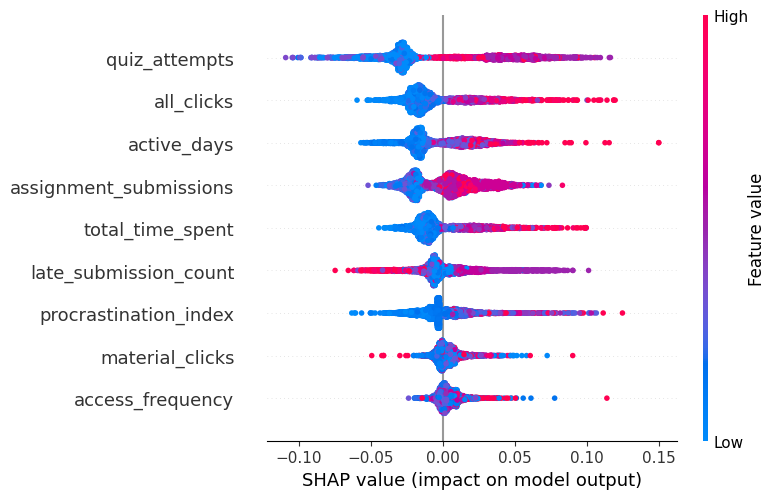

In [12]:
shap.summary_plot(shap_values_high, X_test)

In [13]:
student_index = 5  # Changed from 266286 to a valid index

shap.force_plot(
    explainer.expected_value[1],
    shap_values_high[student_index],
    X_test.iloc[student_index]
)

In [14]:
def generate_shap_recommendations(student_index):
    student_data = X_test.iloc[student_index]
    student_shap = shap_values_high[student_index]
    probability = model.predict_proba([student_data])[0][1]

    recs = []

    if probability < 0.5:
        recs.append("Student is predicted as Not High Performer.")

    # Get negative impact features
    for feature, shap_value in zip(X.columns, student_shap):
        if shap_value < -0.02:  # threshold
            if feature == "procrastination_index":
                recs.append("High procrastination is reducing performance.")
            if feature == "late_submission_count":
                recs.append("Frequent late submissions are negatively impacting performance.")
            if feature == "access_frequency":
                recs.append("Low access frequency is reducing engagement.")
            if feature == "total_time_spent":
                recs.append("Low study time is lowering performance probability.")
            if feature == "quiz_attempts":
                recs.append("Low quiz practice is weakening mastery.")

    return {
        "Probability": probability,
        "Classification": "High Performer" if probability >= 0.5 else "Not High Performer",
        "Recommendations": recs
    }


In [15]:
import joblib

joblib.dump(model, "performance_model.pkl")
joblib.dump(behavior_features, "feature_list.pkl")

['feature_list.pkl']

In [16]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model, X, y, cv=5, scoring="roc_auc"
)

print("Cross-validated ROC-AUC:", cv_scores.mean())


Cross-validated ROC-AUC: 0.8140094746763008


In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [8, 10, 12],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)


Best Params: {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}
Best ROC-AUC: 0.8320032847492801


In [18]:
print(y.value_counts(normalize=True))


high_performer
0    0.900929
1    0.099071
Name: proportion, dtype: float64
